# Comprensión y análisis exploratorio de datos
A diferencia del notebook `Cargar_datos.ipynb`, donde se validó la lectura, estructura inicial, nulos y duplicados, en este notebook el objetivo es comprender el comportamiento de las variables y su relación con la variable objetivo `Pago_atiempo`.

El análisis se enfoca en identificar patrones, posibles relaciones relevantes y hallazgos que orienten la ingeniería de características y el entrenamiento de modelos supervisados.

Utilizaremos librerías de análisis y visualización para explorar la base de datos desde una perspectiva descriptiva.

In [34]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ruta_csv = Path("../Base_de_datos.csv")

if not ruta_csv.exists():
    ruta_csv = Path("Base_de_datos.csv")

df = pd.read_csv(ruta_csv)
df_eda = df.copy()

df_eda.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


### 1. Contexto del problema

El proyecto se desarrolla en el contexto de una empresa financiera que desea anticipar el comportamiento de pago de nuevos usuarios a partir de información histórica de créditos.

La variable objetivo es `Pago_atiempo`, que indica si un cliente realizó su pago dentro del tiempo esperado. A partir de esta variable se construirá posteriormente un modelo supervisado de clasificación. Desde una perspectiva de negocio, este análisis puede ayudar a identificar perfiles de clientes con mayor o menor probabilidad de pago oportuno, lo que permitiría apoyar decisiones relacionadas con evaluación crediticia, gestión de riesgo y seguimiento de clientes.

Para mantener intacta la base original cargada, trabajaremos sobre una copia llamada `df_eda`, en la cual realizaremos ajustes de tipos de datos y revisiones exploratorias.

In [35]:
df_eda = df.copy()
df_eda.shape

(10763, 23)

### 2. Variable objetivo

Antes de analizar las variables predictoras, revisaremos la distribución de `Pago_atiempo`, ya que esto permite conocer si el problema presenta desbalance entre clases.


In [36]:
objetivo_df = df_eda["Pago_atiempo"].value_counts().sort_index().reset_index()
objetivo_df.columns = ["Pago_atiempo", "conteo"]
objetivo_df["porcentaje"] = (objetivo_df["conteo"] / len(df_eda) * 100).round(2)

objetivo_df

,Pago_atiempo,conteo,porcentaje
0,0,511,4.75
1,1,10252,95.25


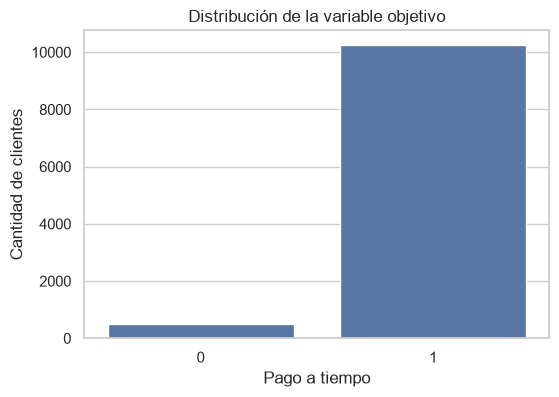

In [37]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_eda,
    x="Pago_atiempo"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Pago a tiempo")
plt.ylabel("Cantidad de clientes")
plt.show()

La variable `Pago_atiempo` presenta un desbalance considerable entre clases. La mayoría de los registros corresponde a clientes que sí pagaron a tiempo, con aproximadamente 95.25% de los casos, mientras que la clase de clientes que no pagaron a tiempo representa cerca del 4.75%.

Este hallazgo es importante porque el problema de clasificación no está equilibrado. Si más adelante se evalúa el modelo únicamente con accuracy, podríamos obtener un resultado aparentemente alto aunque el modelo no aprenda correctamente a identificar a los clientes que no pagan a tiempo. Por esta razón, en la etapa de modelado será necesario considerar métricas como precision, recall, F1-score, matriz de confusión y ROC-AUC.

### 3. Análisis univariable

En esta sección analizaremos variables individuales para comprender su comportamiento general. El objetivo es observar distribuciones, rangos, valores atípicos y concentración de categorías antes de estudiar su relación con la variable objetivo `Pago_atiempo`.

**Variables numéricas principales**

Se seleccionan variables numéricas relevantes para el problema financiero, como monto del crédito, plazo, edad, salario, cuota pactada, puntaje crediticio y saldos.

In [38]:
variables_numericas = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "cuota_pactada",
    "puntaje_datacredito",
    "saldo_total",
    "promedio_ingresos_datacredito"
]

df_eda[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
capital_prestado,10763.0,2.434315e+06,1.909643e+06,360000.0,1224831.0,1921920.0,3084840.0,4.144415e+07
plazo_meses,10763.0,1.057558e+01,6.632082e+00,2.0,6.0,10.0,12.0,9.000000e+01
edad_cliente,10763.0,4.394862e+01,1.506088e+01,19.0,33.0,42.0,53.0,1.230000e+02
salario_cliente,10763.0,1.721643e+07,3.554767e+08,0.0,2000000.0,3000000.0,4875808.0,2.200000e+10
cuota_pactada,10763.0,2.436174e+05,2.104937e+05,23944.0,121041.5,182863.0,287833.5,3.816752e+06
puntaje_datacredito,10757.0,7.807908e+02,1.048780e+02,-7.0,757.0,791.0,825.0,9.990000e+02
saldo_total,10607.0,4.593741e+04,1.062698e+05,0.0,2898.0,16178.0,52982.0,5.116066e+06
promedio_ingresos_datacredito,7833.0,2.005157e+06,2.144116e+06,0.0,925157.0,1204496.0,2231859.0,3.810658e+07


La descripción estadística inicial permite observar diferencias importantes en escala entre las variables financieras. Algunas columnas, como `salario_cliente`, `capital_prestado` y `saldo_total`, pueden presentar valores extremos, por lo que será necesario revisarlas con gráficas y considerar su tratamiento en etapas posteriores.

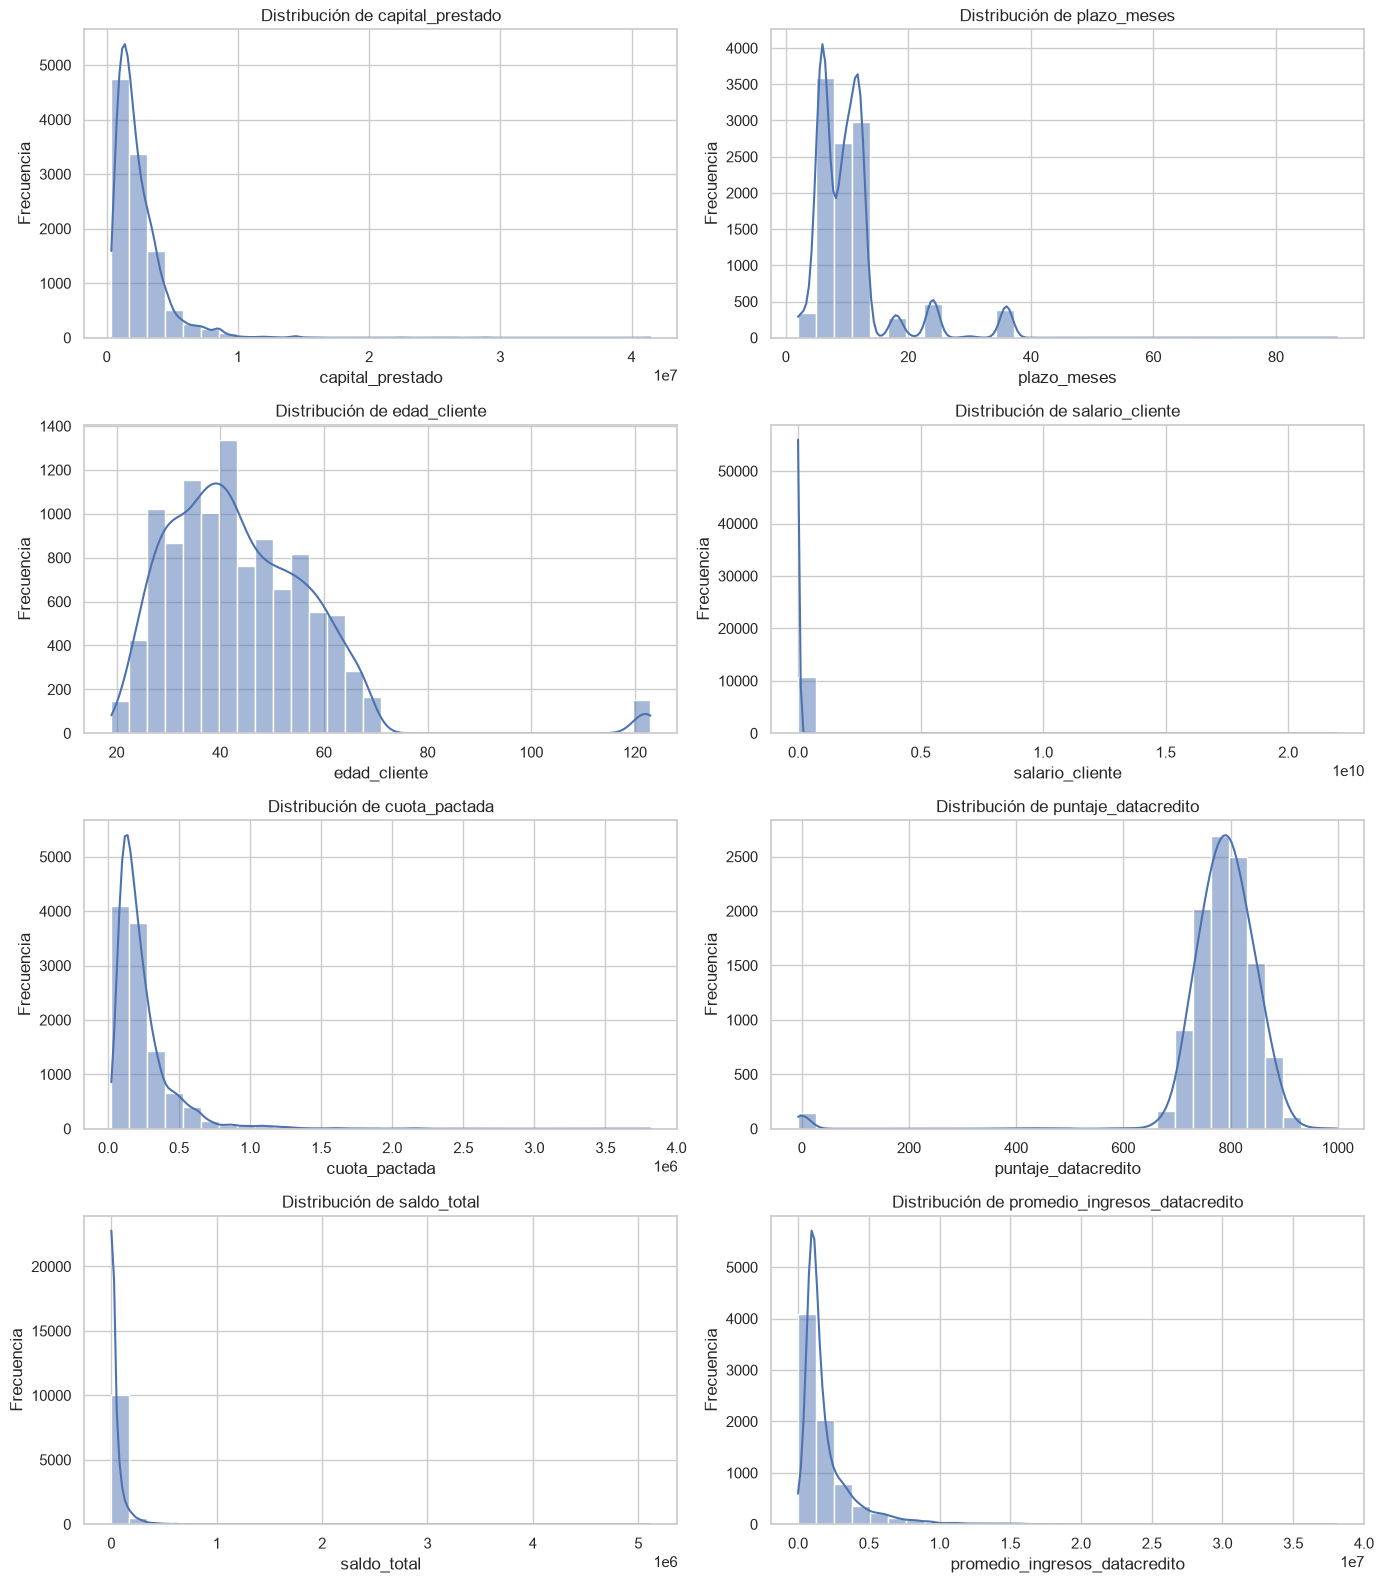

In [39]:
from math import ceil

variables_numericas = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "cuota_pactada",
    "puntaje_datacredito",
    "saldo_total",
    "promedio_ingresos_datacredito"
]
variables_numericas = [
    variable for variable in variables_numericas
    if variable in df_eda.columns
]

columnas = 2
filas = ceil(len(variables_numericas) / columnas)

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(14, filas * 4)
)
axes = axes.flatten()

for i, variable in enumerate(variables_numericas):
    sns.histplot(
        data=df_eda,
        x=variable,
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {variable}")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Frecuencia")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Las variables numéricas muestran diferencias importantes de escala y varias distribuciones asimétricas. Variables como `capital_prestado`, `cuota_pactada`, `saldo_total`, `salario_cliente` y `promedio_ingresos_datacredito` presentan concentración en valores bajos o medios, pero también incluyen valores extremos altos.

En particular, `salario_cliente` muestra una dispersión muy amplia, con valores que se alejan bastante del comportamiento central de la variable. Esto sugiere que podrían existir registros atípicos o valores que requieren revisión durante la ingeniería de características. También se observan valores poco comunes en `edad_cliente` y `puntaje_datacredito`, por lo que estas columnas deberán validarse antes del entrenamiento.

En general, el análisis univariable indica que varias variables financieras podrían necesitar transformación, escalamiento o tratamiento de outliers para evitar que los modelos se vean influenciados por valores extremos.

**Variables categóricas principales**

Se revisan las variables categóricas más relevantes del dataset. Aunque `tipo_credito` aparece como valor numérico, se analiza como variable categórica porque representa códigos o tipos de crédito.

In [40]:
variables_categoricas = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos"
]

for variable in variables_categoricas:
    tabla = df_eda[variable].value_counts(dropna=False).reset_index()
    tabla.columns = [variable, "conteo"]
    tabla["porcentaje"] = (tabla["conteo"] / len(df_eda) * 100).round(2)
    
    display(tabla)

,tipo_credito,conteo,porcentaje
0,4,7747,71.98
1,9,2876,26.72
2,10,116,1.08
3,6,21,0.20
4,7,2,0.02
5,68,1,0.01


,tipo_laboral,conteo,porcentaje
0,Empleado,6754,62.75
1,Independiente,4009,37.25


,tendencia_ingresos,conteo,porcentaje
0,Creciente,5294,49.19
1,NaN,2932,27.24
2,Decreciente,1291,11.99
3,Estable,1188,11.04
4,0,7,0.07
5,8315,6,0.06
6,1000000,4,0.04
7,9147,2,0.02
8,158042,1,0.01
9,3978,1,0.01


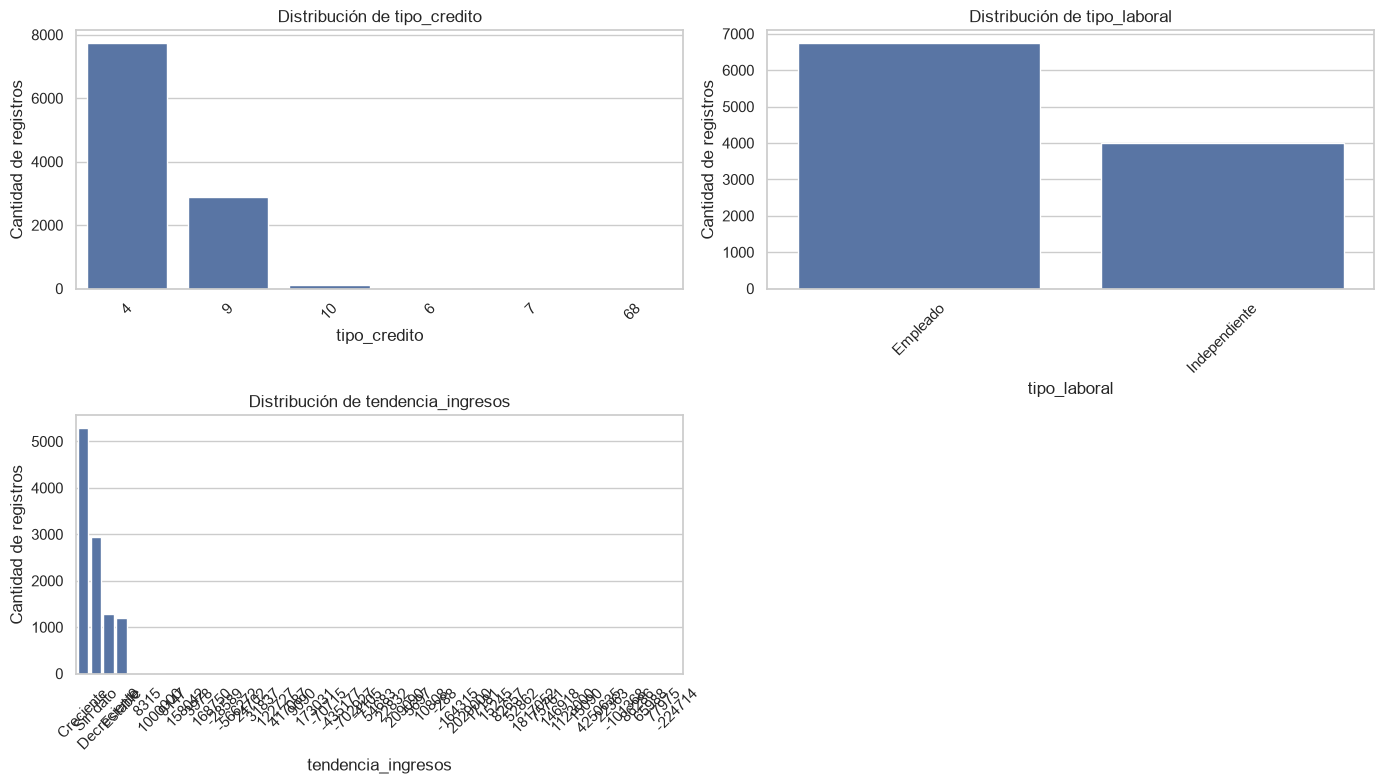

In [41]:
variables_categoricas = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos"
]

variables_categoricas = [
    variable for variable in variables_categoricas
    if variable in df_eda.columns
]

columnas = 2
filas = ceil(len(variables_categoricas) / columnas)

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(14, filas * 4)
)

axes = axes.flatten()

for i, variable in enumerate(variables_categoricas):
    temp_df = df_eda[[variable]].copy()
    temp_df[variable] = temp_df[variable].astype("string").fillna("Sin dato")
    
    orden = temp_df[variable].value_counts().index
    
    sns.countplot(
        data=temp_df,
        x=variable,
        order=orden,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {variable}")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Cantidad de registros")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Las variables categóricas presentan una concentración clara en pocas clases. En `tipo_credito`, la mayoría de los registros se agrupa en los tipos 4 y 9, mientras que el resto de las categorías tiene una presencia muy baja. Esto puede ser relevante porque algunas categorías minoritarias podrían no aportar suficiente información estadística al modelo o podrían generar problemas de generalización.

En `tipo_laboral`, la base contiene principalmente clientes empleados, aunque también hay una proporción importante de independientes. Esta variable puede ser útil porque representa una diferencia laboral que podría relacionarse con estabilidad de ingresos y comportamiento de pago.

La variable `tendencia_ingresos` requiere especial atención. Aunque las categorías principales son Creciente, Decreciente y Estable, también aparecen valores nulos y registros numéricos que no parecen corresponder a una categoría válida. Esto indica un problema de calidad o codificación que deberá corregirse durante la ingeniería de características antes de usar la variable en el modelo.

### 4. Análisis bivariable

En esta sección analizaremos la relación entre algunas variables predictoras y la variable objetivo `Pago_atiempo`. El objetivo es identificar si ciertos valores, rangos o categorías parecen asociarse con una mayor o menor proporción de pagos a tiempo. Estos hallazgos serán útiles para orientar la ingeniería de características y la selección de modelos.

**Variables numéricas frente a la variable objetivo**

Primero se comparan variables numéricas relevantes contra `Pago_atiempo`. Para esto se utilizan tablas resumen por clase y gráficas de caja, que permiten observar diferencias en medianas, dispersión y posibles valores extremos.

In [42]:
variables_numericas = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "cuota_pactada",
    "puntaje_datacredito",
    "saldo_total",
    "promedio_ingresos_datacredito"
]

variables_numericas = [
    variable for variable in variables_numericas
    if variable in df_eda.columns
]

resumen_numericas_objetivo = df_eda.groupby("Pago_atiempo")[variables_numericas].agg(
    ["mean", "median", "std"]
).round(2)

resumen_numericas_objetivo

capital_prestado                        plazo_meses               \
                         mean     median         std        mean median   std   
Pago_atiempo                                                                    
0                  2781774.11  2268000.0  1942337.70       12.45   10.0  9.27   
1                  2416996.27  1908446.4  1906438.41       10.48   10.0  6.46   

             edad_cliente               salario_cliente             \
                     mean median    std            mean     median   
Pago_atiempo                                                         
0                   41.77   38.0  17.06     23555143.33  3000000.0   
1                   44.06   42.0  14.95     16900485.13  3000000.0   

                           cuota_pactada                      \
                       std          mean    median       std   
Pago_atiempo                                                   
0             2.747876e+08     254755.69  199002.0  201712.0   
1             3.590321e+08     243062.23  182576.0  210915.9   

             puntaje_datacredito                saldo_total           \
                            mean median     std        mean   median   
Pago_atiempo                                                           
0                         748.88  768.0  130.91    39074.92  14518.5   
1                         782.38  792.0  103.16    46276.90  16308.0   

                        promedio_ingresos_datacredito                         
                    std                          mean     median         std  
Pago_atiempo                                                                  
0              63386.03                    1605742.05  1052529.0  1668892.06  
1             107940.63                    2023447.77  1211296.0  2161702.28

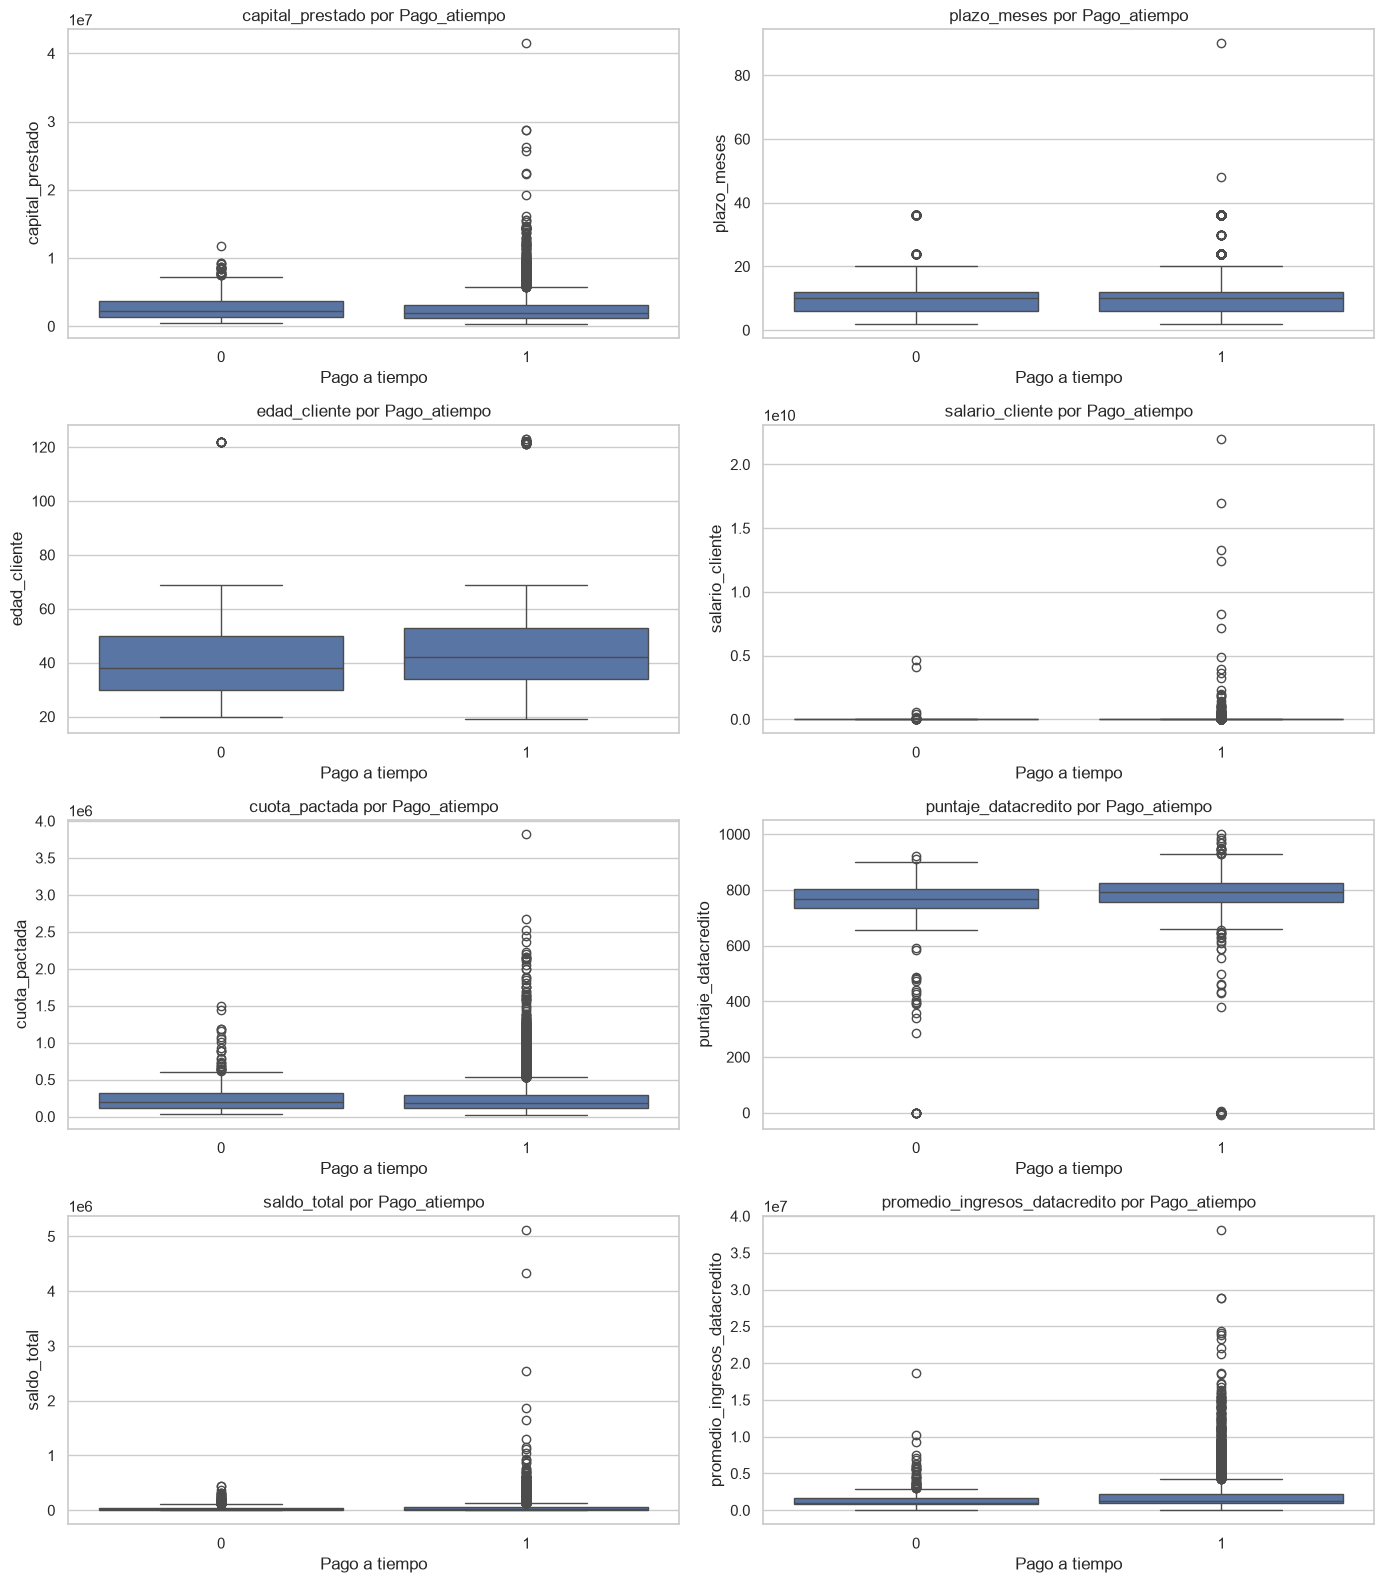

In [43]:
from math import ceil

columnas = 2
filas = ceil(len(variables_numericas) / columnas)

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(14, filas * 4)
)

axes = axes.flatten()

for i, variable in enumerate(variables_numericas):
    sns.boxplot(
        data=df_eda,
        x="Pago_atiempo",
        y=variable,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{variable} por Pago_atiempo")
    axes[i].set_xlabel("Pago a tiempo")
    axes[i].set_ylabel(variable)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Al comparar las variables numéricas con `Pago_atiempo`, se observan algunas diferencias entre clientes que pagaron y no pagaron a tiempo. Los clientes que no pagaron a tiempo presentan, en promedio, un `capital_prestado` mayor que quienes sí pagaron. También muestran un plazo promedio ligeramente más alto, lo que podría indicar que montos más grandes o créditos más largos pueden estar asociados con mayor dificultad de pago.

El `puntaje_datacredito` muestra una diferencia relevante entre clases: los clientes que pagaron a tiempo tienen un puntaje promedio más alto que los que no pagaron. Este comportamiento tiene sentido dentro del contexto financiero, ya que un mejor puntaje crediticio suele asociarse con menor riesgo.

En cambio, variables como `salario_cliente` deben interpretarse con cautela, ya que presentan valores extremos que afectan el promedio. La mediana resulta más estable y muestra que ambos grupos tienen valores centrales similares. Esto refuerza la necesidad de revisar outliers antes de construir el modelo.

**Variables categóricas frente a la variable objetivo**

Ahora se analiza la relación entre variables categóricas y `Pago_atiempo`. Para cada categoría se calcula la proporción de clientes que pagaron o no pagaron a tiempo. Esto ayuda a identificar si ciertas categorías presentan mayor concentración de incumplimiento o pago oportuno.

In [44]:
variables_categoricas = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos"
]

variables_categoricas = [
    variable for variable in variables_categoricas
    if variable in df_eda.columns
]

for variable in variables_categoricas:
    tabla = pd.crosstab(
        df_eda[variable].fillna("Sin dato"),
        df_eda["Pago_atiempo"],
        normalize="index"
    ).mul(100).round(2)
    
    print(f"\nDistribución porcentual de Pago_atiempo por {variable}")
    display(tabla)


Distribución porcentual de Pago_atiempo por tipo_credito


Pago_atiempo,0,1
tipo_credito,,
4,4.69,95.31
6,42.86,57.14
7,0.00,100.00
9,4.73,95.27
10,2.59,97.41
68,0.00,100.00



Distribución porcentual de Pago_atiempo por tipo_laboral


Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.29,95.71
Independiente,5.51,94.49



Distribución porcentual de Pago_atiempo por tendencia_ingresos


Pago_atiempo,0,1
tendencia_ingresos,,
-101368,0.00,100.00
-164315,0.00,100.00
-224714,0.00,100.00
-28589,0.00,100.00
-288,0.00,100.00
-4105,0.00,100.00
-435177,0.00,100.00
-566272,0.00,100.00
-702927,0.00,100.00


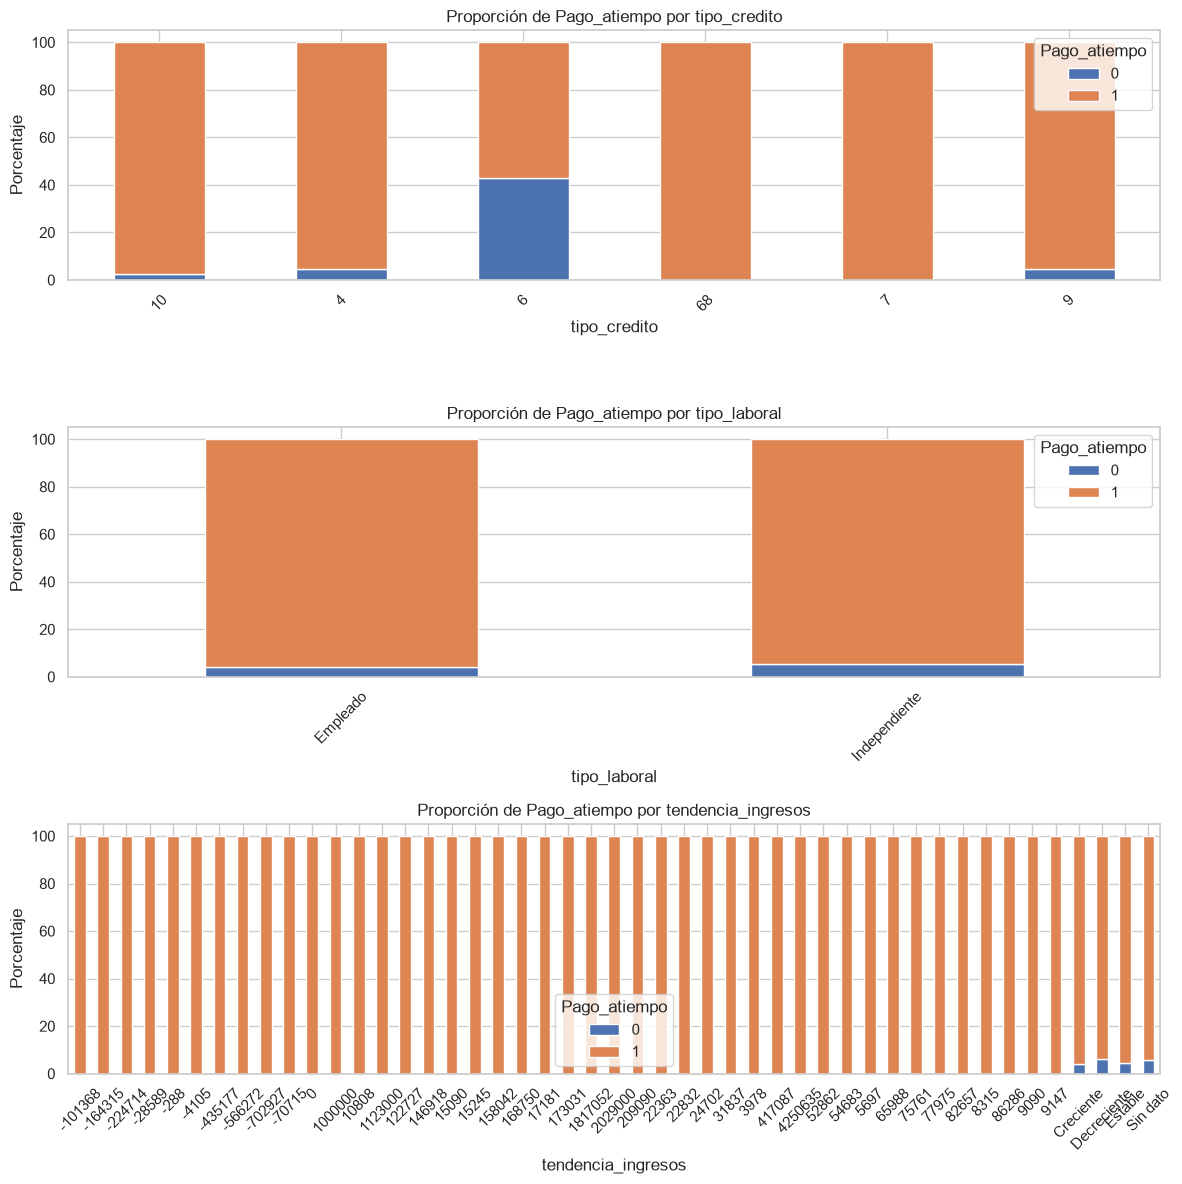

In [45]:
columnas = 1
filas = len(variables_categoricas)

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(12, filas * 4)
)

if filas == 1:
    axes = [axes]

for i, variable in enumerate(variables_categoricas):
    temp_df = df_eda[[variable, "Pago_atiempo"]].copy()
    temp_df[variable] = temp_df[variable].astype("string").fillna("Sin dato")
    
    proporcion = pd.crosstab(
        temp_df[variable],
        temp_df["Pago_atiempo"],
        normalize="index"
    ).mul(100)
    
    proporcion.plot(
        kind="bar",
        stacked=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Proporción de Pago_atiempo por {variable}")
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Porcentaje")
    axes[i].legend(title="Pago_atiempo")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

En las variables categóricas se observan diferencias moderadas entre categorías. Para `tipo_credito`, los tipos 4 y 9 concentran la mayoría de los registros y presentan proporciones de pago a tiempo muy similares, alrededor del 95%. El tipo 6 muestra una proporción mucho mayor de no pago, pero tiene muy pocos registros, por lo que no conviene sacar conclusiones fuertes sólo con esa categoría.

En `tipo_laboral`, los clientes independientes presentan una proporción ligeramente mayor de no pago que los empleados. La diferencia no es extrema, pero puede ser útil para el modelo porque representa una posible señal relacionada con estabilidad laboral o variabilidad de ingresos.

En `tendencia_ingresos`, los clientes con ingresos crecientes muestran una proporción de pago a tiempo más alta que los clientes con ingresos decrecientes o sin dato. Esto sugiere que la tendencia de ingresos puede aportar información relevante para el comportamiento de pago. Sin embargo, antes de utilizarla será necesario limpiar los valores inconsistentes y tratar los registros faltantes.

El análisis bivariable sugiere que no existe una sola variable que explique completamente el comportamiento de pago. Más bien, el riesgo parece depender de una combinación de factores: monto del crédito, plazo, puntaje crediticio, tipo laboral y tendencia de ingresos.

Esto confirma que el problema requiere un modelo supervisado capaz de combinar varias señales al mismo tiempo, en lugar de depender de reglas simples basadas en una sola variable.

### 5. Análisis multivariable

En esta sección analizaremos relaciones entre varias variables al mismo tiempo, con el objetivo de identificar patrones más amplios dentro de la base.

A diferencia del análisis univariable y bivariable, aquí buscamos observar cómo interactúan distintas variables financieras, demográficas y crediticias entre sí, y cómo estas relaciones pueden aportar información para el modelado posterior.

**Correlación entre variables numéricas**

Primero revisaremos la correlación entre las variables numéricas principales. Esto permite detectar relaciones lineales entre variables y observar si alguna de ellas tiene asociación directa o indirecta con la variable objetivo `Pago_atiempo`.

Aunque la correlación no implica causalidad, puede ser útil para identificar variables relacionadas, redundantes o potencialmente relevantes para el modelo.

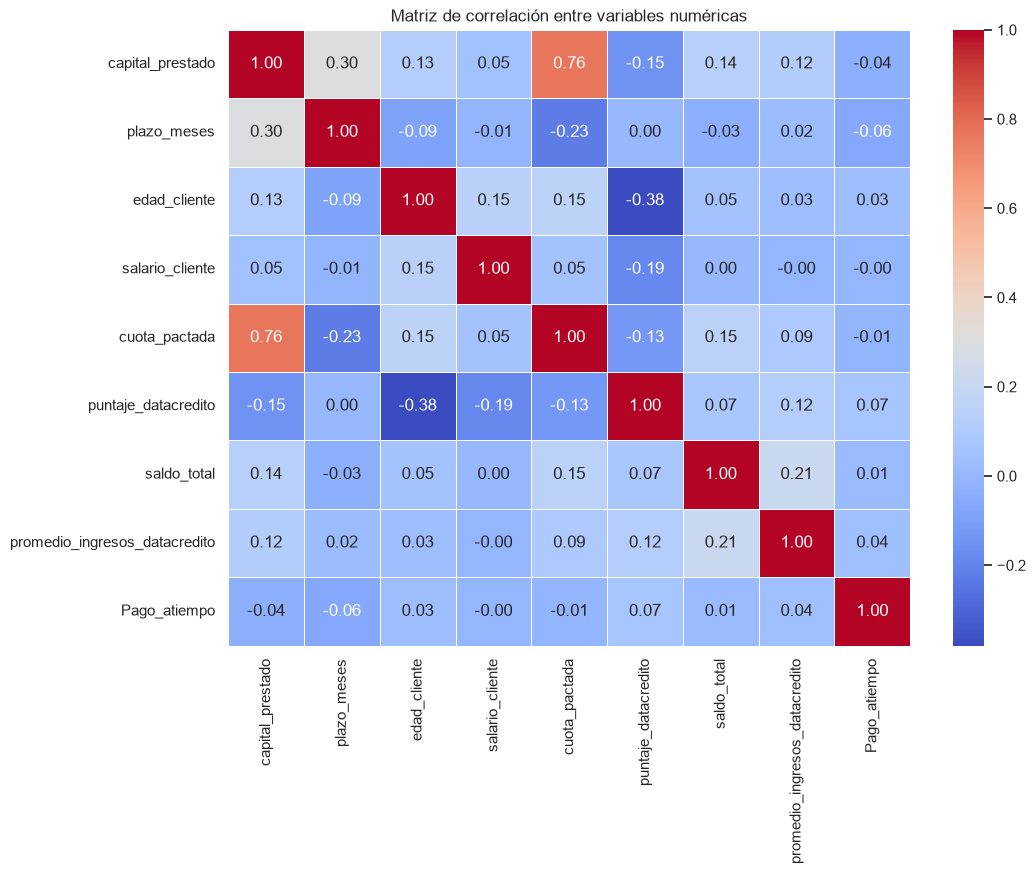

In [46]:
variables_correlacion = [
    "capital_prestado",
    "plazo_meses",
    "edad_cliente",
    "salario_cliente",
    "cuota_pactada",
    "puntaje_datacredito",
    "saldo_total",
    "promedio_ingresos_datacredito",
    "Pago_atiempo"
]

variables_correlacion = [
    variable for variable in variables_correlacion
    if variable in df_eda.columns
]

corr = df_eda[variables_correlacion].corr(numeric_only=True)

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")
plt.show()

La matriz de correlación muestra que la relación lineal entre las variables numéricas y `Pago_atiempo` es baja en general. Esto indica que ninguna variable numérica, por sí sola, tiene una asociación lineal fuerte con la variable objetivo.

La correlación más visible dentro del conjunto aparece entre `capital_prestado` y cuota_pactada, lo cual es esperable: a mayor monto prestado, normalmente también aumenta la cuota. También existe una relación positiva moderada entre `capital_prestado` y `plazo_meses`, ya que créditos más altos pueden requerir plazos más largos.

Respecto a `Pago_atiempo`, el puntaje_datacredito presenta una correlación positiva leve, mientras que `capital_prestado` y `plazo_meses` muestran una correlación negativa leve. Aunque estas relaciones no son fuertes, son coherentes con el contexto financiero: mejores puntajes pueden asociarse con mayor probabilidad de pago oportuno, mientras que créditos más altos o plazos más largos pueden representar mayor riesgo.

**Relación entre salario, capital prestado y variable objetivo**

Para complementar la matriz de correlación, se analiza la relación entre `salario_cliente`, `capital_prestado` y `Pago_atiempo`.

Esta gráfica permite observar si existen zonas donde se concentran clientes con distinto comportamiento de pago considerando simultáneamente ingresos y monto del crédito.

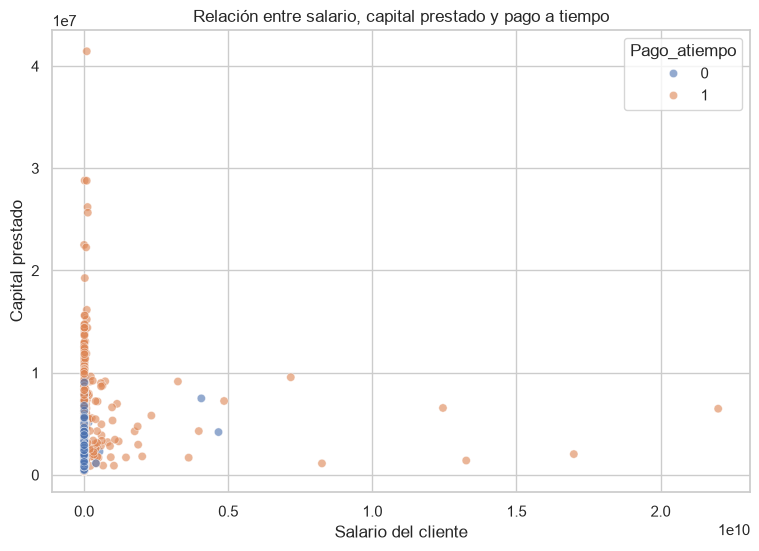

In [47]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_eda,
    x="salario_cliente",
    y="capital_prestado",
    hue="Pago_atiempo",
    alpha=0.6
)

plt.title("Relación entre salario, capital prestado y pago a tiempo")
plt.xlabel("Salario del cliente")
plt.ylabel("Capital prestado")
plt.legend(title="Pago_atiempo")
plt.show()

La relación entre `salario_cliente` y `capital_prestado` muestra una dispersión amplia y presencia de valores extremos. La mayoría de los clientes se concentra en rangos bajos o medios de salario y capital prestado, mientras que algunos registros aparecen muy alejados del resto.

No se observa una separación clara entre clientes que pagaron y no pagaron a tiempo usando únicamente estas dos variables. Esto puede deberse al fuerte desbalance de la variable objetivo, ya que los casos de pago a tiempo dominan visualmente la gráfica. Aun así, la dispersión confirma que será importante tratar valores extremos y posiblemente crear variables derivadas, como relación entre cuota e ingreso o proporción entre capital prestado y salario.

**Relación entre puntaje crediticio, saldo total y variable objetivo**

También se analiza la relación entre `puntaje_datacredito`, `saldo_total` y `Pago_atiempo`, ya que estas variables pueden representar información relevante sobre el perfil crediticio del cliente.

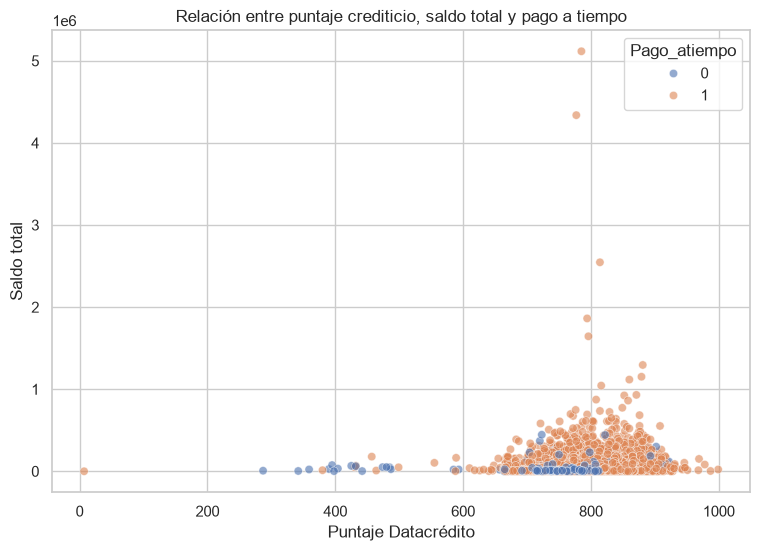

In [48]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_eda,
    x="puntaje_datacredito",
    y="saldo_total",
    hue="Pago_atiempo",
    alpha=0.6
)

plt.title("Relación entre puntaje crediticio, saldo total y pago a tiempo")
plt.xlabel("Puntaje Datacrédito")
plt.ylabel("Saldo total")
plt.legend(title="Pago_atiempo")
plt.show()

La relación entre `puntaje_datacredito`, `saldo_total` y `Pago_atiempo` tampoco muestra una separación completamente clara entre clases, pero sí permite observar algunos patrones útiles. Los clientes con pago a tiempo tienden a concentrarse en puntajes crediticios más altos, mientras que los casos de no pago aparecen con mayor presencia relativa en puntajes más bajos.

El `saldo_total` presenta dispersión y valores extremos, por lo que podría requerir transformación antes del entrenamiento. Esta variable puede aportar información sobre comportamiento financiero previo, pero probablemente será más útil combinada con otras variables que usada de forma aislada.

**Variables financieras según tipo laboral y pago a tiempo**

Finalmente, se analiza el promedio de algunas variables financieras agrupando por `tipo_laboral` y `Pago_atiempo`.

Esto permite observar si el comportamiento financiero cambia entre empleados e independientes, y si esas diferencias también se reflejan en la variable objetivo.

In [49]:
resumen_tipo_laboral = df_eda.groupby(
    ["tipo_laboral", "Pago_atiempo"]
)[
    ["salario_cliente", "capital_prestado", "cuota_pactada", "saldo_total"]
].mean().round(2)

resumen_tipo_laboral

salario_cliente  capital_prestado  cuota_pactada  \
tipo_laboral  Pago_atiempo                                                     
Empleado      0                 37993173.06        2792814.87      232069.51   
              1                 20602951.51        2377132.03      222041.37   
Independiente 0                  4609312.45        2767286.24      284524.88   
              1                 10582443.24        2485022.26      278933.09   

                            saldo_total  
tipo_laboral  Pago_atiempo               
Empleado      0                36412.80  
              1                42923.82  
Independiente 0                42435.71  
              1                51882.20

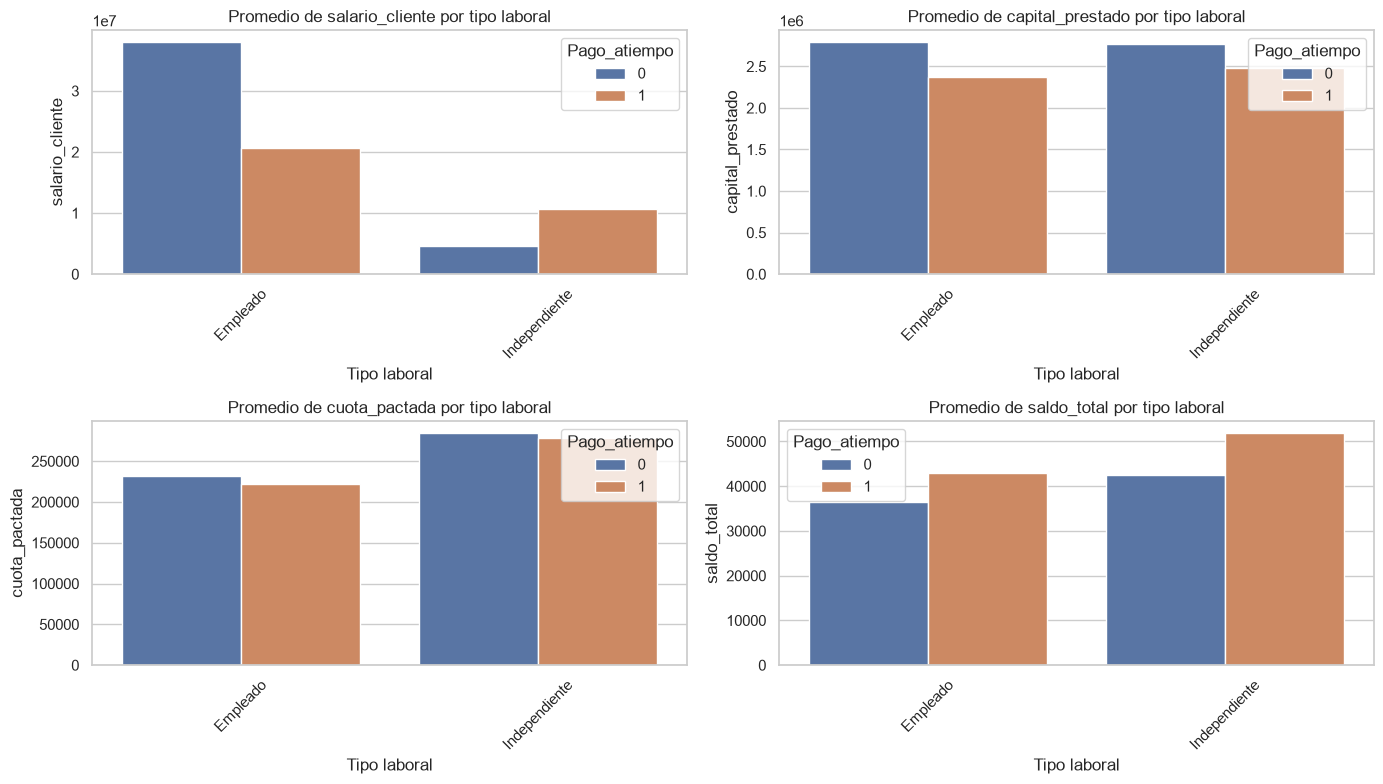

In [50]:
resumen_plot = resumen_tipo_laboral.reset_index()

variables_resumen = [
    "salario_cliente",
    "capital_prestado",
    "cuota_pactada",
    "saldo_total"
]

columnas = 2
filas = ceil(len(variables_resumen) / columnas)

fig, axes = plt.subplots(
    filas,
    columnas,
    figsize=(14, filas * 4)
)

axes = axes.flatten()

for i, variable in enumerate(variables_resumen):
    sns.barplot(
        data=resumen_plot,
        x="tipo_laboral",
        y=variable,
        hue="Pago_atiempo",
        ax=axes[i]
    )
    
    axes[i].set_title(f"Promedio de {variable} por tipo laboral")
    axes[i].set_xlabel("Tipo laboral")
    axes[i].set_ylabel(variable)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

El análisis agrupado por `tipo_laboral` y `Pago_atiempo` muestra diferencias interesantes entre empleados e independientes. En los empleados, el promedio de `salario_cliente` es mayor para quienes no pagaron a tiempo, aunque este resultado debe interpretarse con cautela por la posible presencia de valores extremos. En los independientes ocurre lo contrario: quienes pagaron a tiempo presentan un salario promedio más alto que quienes no pagaron.

También se observa que, tanto en empleados como independientes, los clientes que no pagaron a tiempo tienden a tener un `capital_prestado` promedio ligeramente mayor. Esto refuerza la idea de que el monto del crédito puede estar relacionado con el riesgo de incumplimiento.

En conjunto, este análisis sugiere que `tipo_laboral` puede modificar la forma en que se interpretan variables financieras como salario, capital prestado y cuota pactada. Por ello, durante la ingeniería de características podría ser útil crear variables que relacionen ingresos, monto del crédito y cuota, en lugar de usar únicamente los valores originales.

## 6. Hallazgos principales del EDA

A partir del análisis exploratorio se identificaron varios puntos relevantes para las siguientes etapas del proyecto.

En primer lugar, la variable objetivo `Pago_atiempo` presenta un desbalance importante entre clases. La mayoría de los clientes sí pagaron a tiempo, mientras que los casos de no pago representan una proporción mucho menor. Esto implica que el modelado no debe evaluarse únicamente con accuracy, ya que un modelo podría obtener un resultado alto simplemente prediciendo la clase mayoritaria.

También se observó que varias variables financieras presentan distribuciones asimétricas y valores extremos. Columnas como `salario_cliente`, `capital_prestado`, `cuota_pactada`, `saldo_total` y `promedio_ingresos_datacredito` muestran dispersión considerable. Estos valores no necesariamente deben eliminarse, ya que pueden representar casos reales dentro del negocio financiero, pero sí deben revisarse y tratarse con cuidado durante la ingeniería de características.

El análisis bivariable mostró que los clientes que no pagaron a tiempo tienden a presentar, en promedio, montos de crédito y plazos ligeramente mayores. Además, el `puntaje_datacredito` parece comportarse de forma coherente con el riesgo crediticio: los clientes que pagaron a tiempo muestran puntajes más altos que quienes no lo hicieron.

En las variables categóricas se identificaron diferencias moderadas por `tipo_laboral`, `tipo_credito` y `tendencia_ingresos`. En particular, la variable `tendencia_ingresos` requiere limpieza, ya que contiene valores faltantes e inconsistencias que podrían afectar el entrenamiento si se usan directamente.

Finalmente, el análisis multivariable sugiere que no existe una sola variable que explique por completo el comportamiento de pago. Más bien, el resultado parece depender de la combinación de múltiples factores financieros, laborales y crediticios.


## 7. Implicaciones para la ingeniería de características y modelado

Con base en los hallazgos del EDA, en la siguiente etapa será necesario preparar los datos antes de entrenar los modelos supervisados.

Primero, deberán tratarse los valores faltantes, especialmente en variables como `tendencia_ingresos` y aquellas columnas que presenten nulos en proporciones relevantes. También será importante revisar valores inconsistentes o categorías mal codificadas para evitar que el modelo interprete errores de captura como información válida.

Segundo, las variables categóricas deberán codificarse adecuadamente. Algunas columnas, como `tipo_credito`, aunque están representadas con números, deben tratarse como categorías y no como cantidades continuas. Esto evitará que el modelo asuma relaciones ordinales inexistentes entre los códigos.

Tercero, será conveniente crear variables derivadas que representen mejor la capacidad de pago del cliente. Por ejemplo, podrían construirse relaciones como cuota sobre salario, capital prestado sobre salario o saldo total sobre ingresos. Estas variables pueden aportar más información que los valores originales por separado.

Cuarto, debido al desbalance de la variable objetivo, la evaluación de modelos deberá considerar métricas como precision, recall, F1-score, matriz de confusión y ROC-AUC. Esto permitirá valorar mejor la capacidad del modelo para identificar clientes que no pagan a tiempo, que es una clase minoritaria pero relevante para el negocio.

En conclusión, el EDA muestra que el problema requiere un enfoque de clasificación supervisada con preparación cuidadosa de variables, tratamiento de inconsistencias y evaluación con métricas adecuadas para datos desbalanceados.
